In [3]:
!pip install optuna

Defaulting to user installation because normal site-packages is not writeable


In [4]:
# ── Setup ─────────────────────────────────────────────────────────────────────
# !pip install scikit-learn optuna matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, re, joblib
warnings.filterwarnings('ignore')

from sklearn.datasets import (
    load_iris, load_wine, load_breast_cancer,
    make_regression, make_classification
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, r2_score, mean_squared_error,
    mean_absolute_error, classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

import sklearn, optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('✅ All imports OK')
print(f'   sklearn : {sklearn.__version__}')
print(f'   optuna  : {optuna.__version__}')

✅ All imports OK
   sklearn : 1.8.0
   optuna  : 4.8.0


In [5]:
# ── 1.1  GridWorld Environment ────────────────────────────────────────────────
# 4x4 grid: start=(0,0), goal=(3,3), hole=(1,1)
# Actions: 0=up, 1=down, 2=left, 3=right

GRID_SIZE = 4
N_STATES  = GRID_SIZE * GRID_SIZE   # 16 states
N_ACTIONS = 4
GOAL_STATE = 15   # (3,3)
HOLE_STATE =  5   # (1,1)

MOVES = [(-1,0),(1,0),(0,-1),(0,1)]  # up, down, left, right

def step(state, action):
    row, col = state // GRID_SIZE, state % GRID_SIZE
    dr, dc   = MOVES[action]
    new_row  = max(0, min(GRID_SIZE-1, row + dr))
    new_col  = max(0, min(GRID_SIZE-1, col + dc))
    next_state = new_row * GRID_SIZE + new_col

    if next_state == GOAL_STATE:
        return next_state, +1.0, True
    elif next_state == HOLE_STATE:
        return next_state, -1.0, True
    else:
        return next_state, -0.01, False  # small penalty per step

def render_grid(Q):
    """Show best action arrow for each cell."""
    arrows = ['^','v','<','>']
    print('Grid (best action | Q-value):')
    for r in range(GRID_SIZE):
        row_str = ''
        for c in range(GRID_SIZE):
            s = r * GRID_SIZE + c
            if s == GOAL_STATE: row_str += ' [G]  '
            elif s == HOLE_STATE: row_str += ' [H]  '
            else:
                best_a = Q[s].argmax()
                row_str += f'  {arrows[best_a]}   '
        print(row_str)

print('GridWorld environment ready')
print(f'States: {N_STATES} | Actions: {N_ACTIONS} | Goal: {GOAL_STATE} | Hole: {HOLE_STATE}')

GridWorld environment ready
States: 16 | Actions: 4 | Goal: 15 | Hole: 5


In [6]:
# ── 1.2  Q-Learning Training Loop ─────────────────────────────────────────────
ALPHA    = 0.1     # learning rate
GAMMA    = 0.95    # discount factor
EPSILON  = 1.0     # start fully exploring
EPS_DECAY = 0.995
EPS_MIN  = 0.01
N_EPISODES = 800
MAX_STEPS  = 100

Q = np.zeros((N_STATES, N_ACTIONS))
episode_rewards = []
episode_steps   = []
epsilon = EPSILON

for ep in range(N_EPISODES):
    state = 0  # always start at (0,0)
    total_reward = 0
    epsilon = max(EPS_MIN, epsilon * EPS_DECAY)

    for step_n in range(MAX_STEPS):
        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = np.random.randint(N_ACTIONS)   # explore
        else:
            action = Q[state].argmax()               # exploit

        next_state, reward, done = step(state, action)

        # Bellman update
        Q[state, action] += ALPHA * (
            reward + GAMMA * Q[next_state].max() - Q[state, action]
        )
        state        = next_state
        total_reward += reward
        if done:
            break

    episode_rewards.append(total_reward)
    episode_steps.append(step_n + 1)

# Smooth with rolling window
window = 50
smooth_rewards = pd.Series(episode_rewards).rolling(window).mean()

print(f'Training complete ({N_EPISODES} episodes)')
print(f'Last {window} ep avg reward : {np.mean(episode_rewards[-window:]):.4f}')
print(f'Last {window} ep avg steps  : {np.mean(episode_steps[-window:]):.1f}')
print(f'Final epsilon               : {epsilon:.4f}')

Training complete (800 episodes)
Last 50 ep avg reward : 0.9100
Last 50 ep avg steps  : 6.0
Final epsilon               : 0.0181


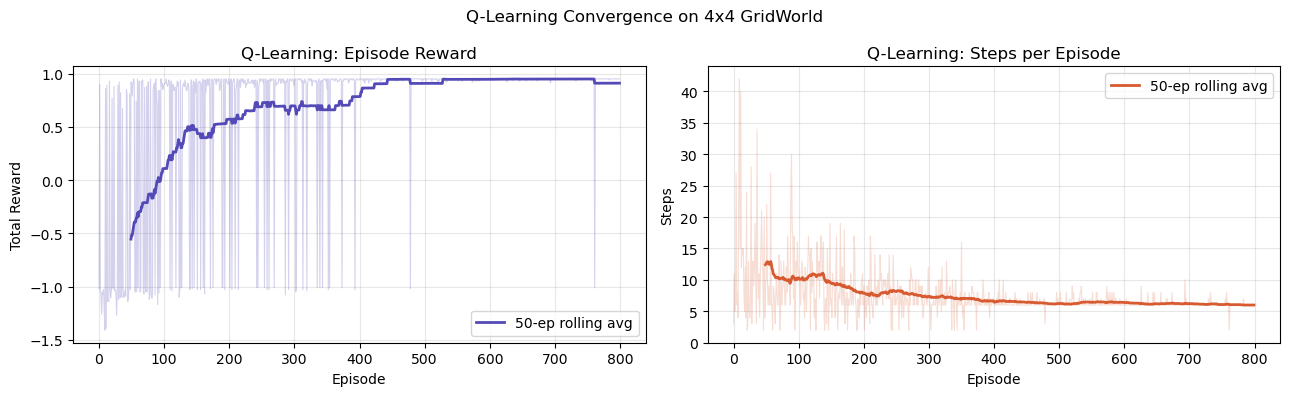

In [7]:
# ── 1.3  Plot Training Curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(episode_rewards, alpha=0.25, color='#534AB7', linewidth=0.8)
axes[0].plot(smooth_rewards, color='#534AB7', linewidth=2, label=f'{window}-ep rolling avg')
axes[0].set_title('Q-Learning: Episode Reward')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Total Reward')
axes[0].legend(); axes[0].grid(alpha=0.3)

smooth_steps = pd.Series(episode_steps).rolling(window).mean()
axes[1].plot(episode_steps, alpha=0.2, color='#D85A30', linewidth=0.8)
axes[1].plot(smooth_steps, color='#D85A30', linewidth=2, label=f'{window}-ep rolling avg')
axes[1].set_title('Q-Learning: Steps per Episode')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Steps')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Q-Learning Convergence on 4x4 GridWorld', fontsize=12)
plt.tight_layout(); plt.show()

Learned Q-Table (state × action):
          Up   Down   Left  Right
State                            
0      0.667  0.302  0.639  0.729
1      0.710 -0.998  0.667  0.777
2      0.660  0.754  0.694  0.829
3      0.759  0.883  0.741  0.772
4      0.206  0.466 -0.013 -0.902
5      0.000  0.000  0.000  0.000
6      0.409  0.415 -0.815  0.880
7      0.748  0.940  0.790  0.843
8      0.017  0.641  0.127  0.048
9     -0.410  0.142  0.049  0.276
10     0.289  0.918  0.017  0.516
11     0.805  1.000  0.780  0.927
12     0.094  0.153  0.173  0.796
13     0.049  0.237  0.157  0.918
14     0.433  0.429  0.247  1.000
15     0.000  0.000  0.000  0.000

Grid (best action | Q-value):
  >     >     >     v   
  v    [H]    >     v   
  v     >     v     v   
  >     >     >    [G]  


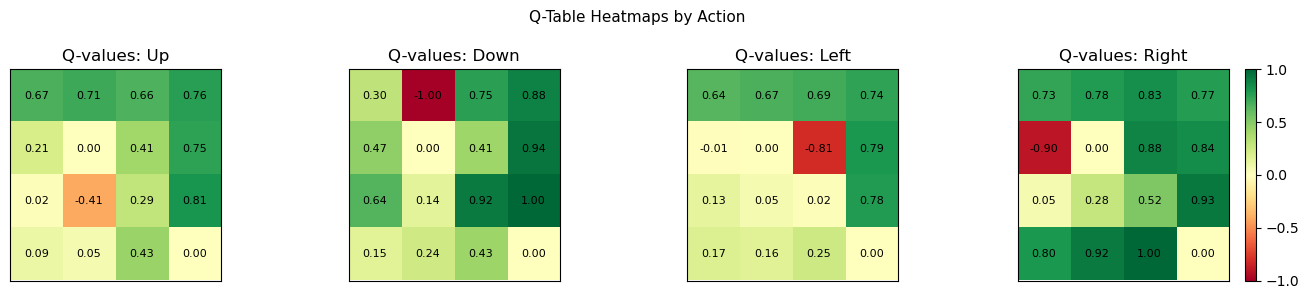

In [8]:
# ── 1.4  Visualise Learned Q-Table ───────────────────────────────────────────
print('Learned Q-Table (state × action):')
q_df = pd.DataFrame(Q, columns=['Up','Down','Left','Right'])
q_df.index.name = 'State'
print(q_df.round(3).to_string())

print()
render_grid(Q)

# Visualise Q-values as heatmap
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
action_names = ['Up', 'Down', 'Left', 'Right']
for i, (ax, name) in enumerate(zip(axes, action_names)):
    grid = Q[:, i].reshape(4, 4)
    im = ax.imshow(grid, cmap='RdYlGn', vmin=-1, vmax=1)
    ax.set_title(f'Q-values: {name}')
    ax.set_xticks([]); ax.set_yticks([])
    for r in range(4):
        for c in range(4):
            ax.text(c, r, f'{grid[r,c]:.2f}', ha='center', va='center',
                    fontsize=8, color='black')
plt.colorbar(im, ax=axes[-1])
plt.suptitle('Q-Table Heatmaps by Action', fontsize=11)
plt.tight_layout(); plt.show()

In [9]:
# ── 1.5  Run Greedy Policy (no exploration) ───────────────────────────────────
state = 0
path  = [state]
total_r = 0

for _ in range(30):
    action = Q[state].argmax()          # pure exploitation
    state, r, done = step(state, action)
    path.append(state)
    total_r += r
    if done:
        break

arrows = ['^','v','<','>']
action_names_full = ['Up','Down','Left','Right']
print('Greedy policy path (state → action):')
for i in range(len(path)-1):
    s = path[i]
    a = Q[s].argmax()
    print(f'  State {s:2d} ({s//4},{s%4}) → {action_names_full[a]:5s} → State {path[i+1]}')
outcome = 'GOAL reached!' if path[-1] == GOAL_STATE else 'Fell in HOLE!' if path[-1] == HOLE_STATE else 'Timeout'
print(f'\nOutcome: {outcome} | Steps: {len(path)-1} | Total reward: {total_r:.3f}')

Greedy policy path (state → action):
  State  0 (0,0) → Right → State 1
  State  1 (0,1) → Right → State 2
  State  2 (0,2) → Right → State 3
  State  3 (0,3) → Down  → State 7
  State  7 (1,3) → Down  → State 11
  State 11 (2,3) → Down  → State 15

Outcome: GOAL reached! | Steps: 6 | Total reward: 0.950


In [10]:
# ── 2.1  Polynomial & Interaction Features ────────────────────────────────────
bc = load_breast_cancer(as_frame=True)
X_bc, y_bc = bc.data, bc.target

# Use first 6 features to keep it fast
X_small = X_bc.iloc[:, :6]

# Degree-2 polynomial: x², x·y terms
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(X_small)

# Interaction only (no squared terms)
interact = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_inter  = interact.fit_transform(X_small)

print(f'Original features      : {X_small.shape[1]}')
print(f'After degree-2 poly    : {X_poly.shape[1]}')
print(f'After interaction only : {X_inter.shape[1]}')

# Compare accuracy before/after
for name, X_use in [('Original', X_small.values), ('+ Polynomial', X_poly), ('+ Interaction', X_inter)]:
    sc = cross_val_score(RandomForestClassifier(50, random_state=42), X_use, y_bc, cv=5).mean()
    print(f'  {name:18s} CV accuracy: {sc:.4f}')

Original features      : 6
After degree-2 poly    : 27
After interaction only : 21
  Original           CV accuracy: 0.9279
  + Polynomial       CV accuracy: 0.9332
  + Interaction      CV accuracy: 0.9350


In [11]:
# ── 2.2  SelectKBest with Mutual Information ──────────────────────────────────
# Rank ALL 30 features by mutual information with target
mi_scores = mutual_info_classif(X_bc, y_bc, random_state=42)
mi_df = pd.DataFrame({'feature': bc.feature_names, 'MI score': mi_scores})\
          .sort_values('MI score', ascending=False)

print('Feature ranking by Mutual Information:')
print(mi_df.head(10).to_string(index=False))

# Select top 8 and compare
sel8 = SelectKBest(mutual_info_classif, k=8).fit_transform(X_bc, y_bc)
sc_all = cross_val_score(RandomForestClassifier(50, random_state=42), X_bc.values, y_bc, cv=5).mean()
sc_sel = cross_val_score(RandomForestClassifier(50, random_state=42), sel8, y_bc, cv=5).mean()
print(f'\nAll 30 features → CV accuracy: {sc_all:.4f}')
print(f'Top 8  features → CV accuracy: {sc_sel:.4f}')

Feature ranking by Mutual Information:
             feature  MI score
     worst perimeter  0.471842
          worst area  0.464313
        worst radius  0.451230
 mean concave points  0.438806
worst concave points  0.436255
      mean perimeter  0.402361
      mean concavity  0.375447
         mean radius  0.362276
           mean area  0.360023
          area error  0.340759

All 30 features → CV accuracy: 0.9543
Top 8  features → CV accuracy: 0.9455


In [12]:
# ── 2.3  Custom Feature Engineering on Wine ──────────────────────────────────
wine = load_wine(as_frame=True)
df_w = wine.data.copy()

# Domain-style engineered features
df_w['alcohol_acidity_ratio']  = df_w['alcohol'] / (df_w['malic_acid'] + 1e-5)
df_w['color_hue_product']      = df_w['color_intensity'] * df_w['hue']
df_w['flavanoids_squared']     = df_w['flavanoids'] ** 2
df_w['log_proline']            = np.log1p(df_w['proline'])
df_w['phenols_diff']           = df_w['total_phenols'] - df_w['nonflavanoid_phenols']
df_w['ash_alcalinity_ratio']   = df_w['ash'] / (df_w['alcalinity_of_ash'] + 1e-5)

original_score = cross_val_score(RandomForestClassifier(50, random_state=42),
                                  wine.data, wine.target, cv=5).mean()
enhanced_score = cross_val_score(RandomForestClassifier(50, random_state=42),
                                  df_w, wine.target, cv=5).mean()

print(f'Original features ({wine.data.shape[1]}) → CV accuracy: {original_score:.4f}')
print(f'Enhanced features ({df_w.shape[1]})  → CV accuracy: {enhanced_score:.4f}')
print(f'Improvement: {(enhanced_score - original_score)*100:+.2f}%')

Original features (13) → CV accuracy: 0.9610
Enhanced features (19)  → CV accuracy: 0.9776
Improvement: +1.67%


In [13]:
# ── 2.4  Binning + Target Encoding ───────────────────────────────────────────
np.random.seed(42)
n = 500
df_bin = pd.DataFrame({
    'income': np.random.exponential(40000, n),
    'age':    np.random.randint(18, 70, n),
    'city':   np.random.choice(['Mumbai','Delhi','Bangalore','Chennai'], n),
    'target': np.random.randint(0, 2, n)
})

# Binning continuous feature
df_bin['income_bin'] = pd.qcut(df_bin['income'], q=4,
                                labels=['low','medium','high','very_high'])
df_bin['age_bin']    = pd.cut(df_bin['age'], bins=[18,30,45,60,70],
                               labels=['young','mid','senior','elder'])

# Target encoding (mean target per category)
city_target_mean = df_bin.groupby('city')['target'].mean()
df_bin['city_encoded'] = df_bin['city'].map(city_target_mean)

print('Binning result:')
print(df_bin[['income','income_bin','age','age_bin','city','city_encoded']].head(8).to_string(index=False))
print('\nCity target encoding:')
print(city_target_mean.round(3))

Binning result:
       income income_bin  age age_bin      city  city_encoded
 18770.723599     medium   34     mid     Delhi      0.561538
120404.857237  very_high   26   young Bangalore      0.445255
 52669.827742       high   50  senior    Mumbai      0.515385
 36517.702151       high   37     mid     Delhi      0.561538
  6784.994818        low   30   young   Chennai      0.466019
  6783.851677        low   45     mid    Mumbai      0.515385
  2393.550744        low   65   elder     Delhi      0.561538
 80449.234579  very_high   46  senior Bangalore      0.445255

City target encoding:
city
Bangalore    0.445
Chennai      0.466
Delhi        0.562
Mumbai       0.515
Name: target, dtype: float64


In [15]:
# ── 3.1  Optuna: Bayesian Hyperparameter Optimisation ────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_w, y_w = load_wine(return_X_y=True)

def objective(trial):
    model_type = trial.suggest_categorical('model', ['rf', 'gb'])

    if model_type == 'rf':
        clf = RandomForestClassifier(
            n_estimators   = trial.suggest_int('n_estimators', 20, 150),
            max_depth      = trial.suggest_int('max_depth', 2, 15),
            min_samples_split = trial.suggest_int('min_samples_split', 2, 10),
            random_state   = 42
        )
    else:
        clf = GradientBoostingClassifier(
            n_estimators   = trial.suggest_int('n_estimators', 20, 150),
            max_depth      = trial.suggest_int('max_depth', 2, 8),
            learning_rate  = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            random_state   = 42
        )
    return cross_val_score(clf, X_w, y_w, cv=5, scoring='accuracy').mean()

study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=False)

print(f'Best CV accuracy : {study.best_value:.4f}')
print(f'Best params      : {study.best_params}')
print(f'Best model type  : {study.best_params["model"]}')

Best CV accuracy : 0.9778
Best params      : {'model': 'rf', 'n_estimators': 69, 'max_depth': 12, 'min_samples_split': 4}
Best model type  : rf


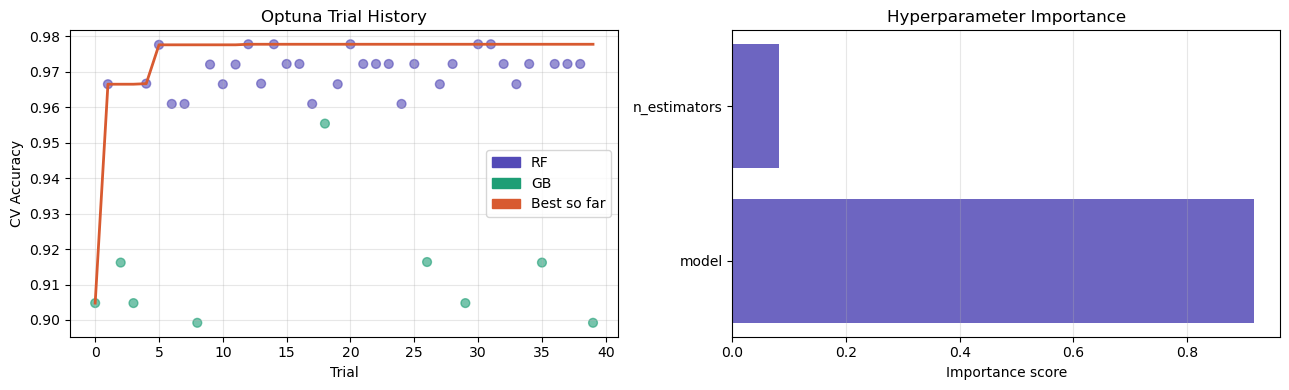

In [16]:
# ── 3.2  Optuna Trial History ─────────────────────────────────────────────────
trials_df = study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Trial values over time
axes[0].scatter(trials_df.index, trials_df['value'], alpha=0.6,
                c=['#534AB7' if m=='rf' else '#1D9E75'
                   for m in trials_df['params_model']], s=40)
best_so_far = trials_df['value'].cummax()
axes[0].plot(best_so_far, color='#D85A30', linewidth=2, label='Best so far')
axes[0].set_title('Optuna Trial History')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('CV Accuracy')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#534AB7',label='RF'),
                          Patch(color='#1D9E75',label='GB'),
                          Patch(color='#D85A30',label='Best so far')])
axes[0].grid(alpha=0.3)

# Importance of hyperparameters
try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()),
                 color='#534AB7', alpha=0.85)
    axes[1].set_title('Hyperparameter Importance')
    axes[1].set_xlabel('Importance score')
    axes[1].grid(axis='x', alpha=0.3)
except:
    axes[1].text(0.5, 0.5, 'Run more trials for importance', ha='center', va='center',
                 transform=axes[1].transAxes)

plt.tight_layout(); plt.show()

In [17]:
# ── 3.3  TF-IDF Vectorisation ─────────────────────────────────────────────────
# Synthetic news headlines dataset (no download needed)
texts = [
    # Positive (label=1)
    "Scientists discover breakthrough in cancer treatment using AI",
    "Stock market reaches all-time high driven by tech sector growth",
    "New renewable energy record set by solar farm in India",
    "Machine learning model predicts climate patterns with 95% accuracy",
    "Startup raises 100 million funding for healthcare innovation",
    "Team wins championship after incredible comeback in final match",
    "City launches free public wifi across all parks and libraries",
    "Electric vehicles sales surge 60 percent year over year globally",
    "New drug approved for rare disease affecting thousands of children",
    "International space station celebrates 25 years of continuous habitation",
    # Negative (label=0)
    "Earthquake damages thousands of homes leaving families displaced",
    "Global inflation hits 40 year high causing economic uncertainty",
    "Wildfire destroys millions of acres across drought stricken region",
    "Company announces massive layoffs affecting 10000 employees worldwide",
    "Flooding kills dozens and forces evacuations across coastal towns",
    "Heatwave breaks records causing health crisis across three states",
    "Bank collapse triggers panic and long queues outside branches",
    "Cyberattack disrupts hospital systems putting patient care at risk",
    "Food shortage worsens as drought hits major agricultural regions",
    "Political crisis deepens as government faces no confidence vote",
]
labels = [1]*10 + [0]*10

# TF-IDF
tfidf = TfidfVectorizer(max_features=50, stop_words='english', ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(texts).toarray()

print(f'Vocabulary size : {len(tfidf.vocabulary_)}')
print(f'Feature matrix  : {X_tfidf.shape}')
print(f'\nTop 15 tokens:')
vocab_sorted = sorted(tfidf.vocabulary_.items(), key=lambda x: x[1])
print([w for w, _ in vocab_sorted[:15]])

Vocabulary size : 50
Feature matrix  : (20, 50)

Top 15 tokens:
['100', 'affecting', 'causing', 'crisis', 'drought', 'high', 'hits', 'inflation hits', 'innovation', 'international', 'international space', 'kills', 'kills dozens', 'launches', 'launches free']


In [18]:
# ── 3.4  Text Classification Pipeline ────────────────────────────────────────
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# More training data using the same synthetic headlines
augmented_texts  = texts * 4  # repeat for cross-val
augmented_labels = labels * 4

text_pipelines = {
    'TF-IDF + LogReg' : make_pipeline(
        TfidfVectorizer(max_features=100, stop_words='english', ngram_range=(1,2)),
        LogisticRegression(max_iter=500)
    ),
    'TF-IDF + LinearSVC': make_pipeline(
        TfidfVectorizer(max_features=100, stop_words='english', ngram_range=(1,2)),
        LinearSVC(max_iter=500)
    ),
    'Count + NaiveBayes': make_pipeline(
        CountVectorizer(max_features=100, stop_words='english'),
        MultinomialNB()
    ),
}

print('Text classification results (5-fold CV):')
for name, pipe in text_pipelines.items():
    scores = cross_val_score(pipe, augmented_texts, augmented_labels, cv=5, scoring='accuracy')
    print(f'  {name:25s}: {scores.mean():.4f} ± {scores.std():.4f}')

Text classification results (5-fold CV):
  TF-IDF + LogReg          : 0.9625 ± 0.0306
  TF-IDF + LinearSVC       : 0.9625 ± 0.0306
  Count + NaiveBayes       : 1.0000 ± 0.0000


In [19]:
# ── 3.5  Regex-Based NLP Feature Extraction ───────────────────────────────────
sample_texts = [
    "Contact us at support@company.com or call +91-9876543210 for help.",
    "Price dropped from $250.00 to $189.99 — save 24% today!",
    "Meeting on 15-03-2025 at 10:30 AM in Room 4B. Ref: TKT-20491.",
    "Visit https://www.example.com/blog for the latest ML tutorials.",
    "Model achieved 97.3% accuracy on 12,000 test samples in 2.4 seconds.",
]

patterns = {
    'emails'   : r'[\w.+-]+@[\w-]+\.[\w.-]+',
    'phones'   : r'[+\d][\d\s\-]{8,}',
    'prices'   : r'\$[\d,]+\.?\d*',
    'percents' : r'\d+\.?\d*\s?%',
    'dates'    : r'\d{1,2}[-/]\d{1,2}[-/]\d{2,4}',
    'urls'     : r'https?://[^\s]+',
    'numbers'  : r'\b\d[\d,]*\.?\d*\b',
}

print('Regex Extraction Results:')
print('='*60)
for text in sample_texts:
    print(f'\nText: "{text[:55]}..."')
    for pat_name, pattern in patterns.items():
        found = re.findall(pattern, text)
        if found:
            print(f'  {pat_name:12s}: {found}')

Regex Extraction Results:

Text: "Contact us at support@company.com or call +91-987654321..."
  emails      : ['support@company.com']
  phones      : ['+91-9876543210 ']
  numbers     : ['91', '9876543210']

Text: "Price dropped from $250.00 to $189.99 — save 24% today!..."
  prices      : ['$250.00', '$189.99']
  percents    : ['24%']
  numbers     : ['250.00', '189.99', '24']

Text: "Meeting on 15-03-2025 at 10:30 AM in Room 4B. Ref: TKT-..."
  phones      : ['15-03-2025 ']
  dates       : ['15-03-2025']
  numbers     : ['15', '03', '2025', '10', '30', '20491']

Text: "Visit https://www.example.com/blog for the latest ML tu..."
  urls        : ['https://www.example.com/blog']

Text: "Model achieved 97.3% accuracy on 12,000 test samples in..."
  percents    : ['97.3%']
  numbers     : ['97.3', '12,000', '2.4']


In [20]:
# ── 5.1  Simulate Competition Dataset ────────────────────────────────────────
np.random.seed(42)
N_TRAIN, N_TEST = 1000, 300

def make_house_data(n, seed=42):
    rng = np.random.default_rng(seed)
    df = pd.DataFrame({
        'area'         : rng.integers(500, 3000, n),
        'bedrooms'     : rng.integers(1, 6, n),
        'bathrooms'    : rng.integers(1, 4, n),
        'age'          : rng.integers(0, 50, n),
        'floors'       : rng.integers(1, 4, n),
        'garage'       : rng.integers(0, 3, n),
        'distance_cbd' : rng.uniform(1, 30, n).round(1),
        'crime_rate'   : rng.uniform(0, 10, n).round(2),
        'school_rating': rng.uniform(3, 10, n).round(1),
        'neighborhood' : rng.choice(['premium','standard','budget'], n),
        'style'        : rng.choice(['modern','classic','colonial'], n),
    })
    # Inject some missing values realistically
    idx = rng.choice(n, size=int(n*0.05), replace=False)
    df.loc[idx, 'garage'] = np.nan
    idx2 = rng.choice(n, size=int(n*0.03), replace=False)
    df.loc[idx2, 'school_rating'] = np.nan
    return df

train_df = make_house_data(N_TRAIN, seed=42)
test_df  = make_house_data(N_TEST, seed=99)

# Generate target: house price
def make_price(df):
    p = (df['area'] * 150 + df['bedrooms'] * 8000 + df['bathrooms'] * 5000
         - df['age'] * 1000 + df['floors'] * 4000 + df['garage'].fillna(0) * 6000
         - df['distance_cbd'] * 2000 - df['crime_rate'] * 3000
         + df['school_rating'].fillna(7) * 5000
         + (df['neighborhood']=='premium') * 50000
         - (df['neighborhood']=='budget') * 20000)
    return p + np.random.normal(0, 15000, len(df))

train_df['price'] = make_price(train_df)
train_id = np.arange(N_TRAIN)
test_id  = np.arange(N_TRAIN, N_TRAIN + N_TEST)

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
print('\nTarget stats:')
print(train_df['price'].describe().round(0))

Train shape: (1000, 12)
Test shape : (300, 11)

Target stats:
count      1000.0
mean     284818.0
std      115718.0
min       19419.0
25%      191061.0
50%      288737.0
75%      376895.0
max      529142.0
Name: price, dtype: float64


=== MISSING VALUES ===
garage           50
school_rating    30
dtype: int64

=== NUMERIC STATS ===
         area  bedrooms  bathrooms     age  floors  garage  distance_cbd  \
count  1000.0    1000.0     1000.0  1000.0  1000.0   950.0        1000.0   
mean   1757.0       3.0        2.0    24.6     2.0     1.0          15.3   
std     721.5       1.4        0.8    14.3     0.8     0.8           8.4   
min     510.0       1.0        1.0     0.0     1.0     0.0           1.0   
25%    1119.8       2.0        1.0    12.0     1.0     0.0           8.2   
50%    1764.5       3.0        2.0    24.5     2.0     1.0          15.4   
75%    2395.2       4.0        3.0    37.0     3.0     2.0          22.6   
max    2997.0       5.0        3.0    49.0     3.0     2.0          30.0   

       crime_rate  school_rating     price  
count      1000.0          970.0    1000.0  
mean          4.9            6.4  284818.2  
std           2.8            2.0  115717.7  
min           0.0            3.0   1

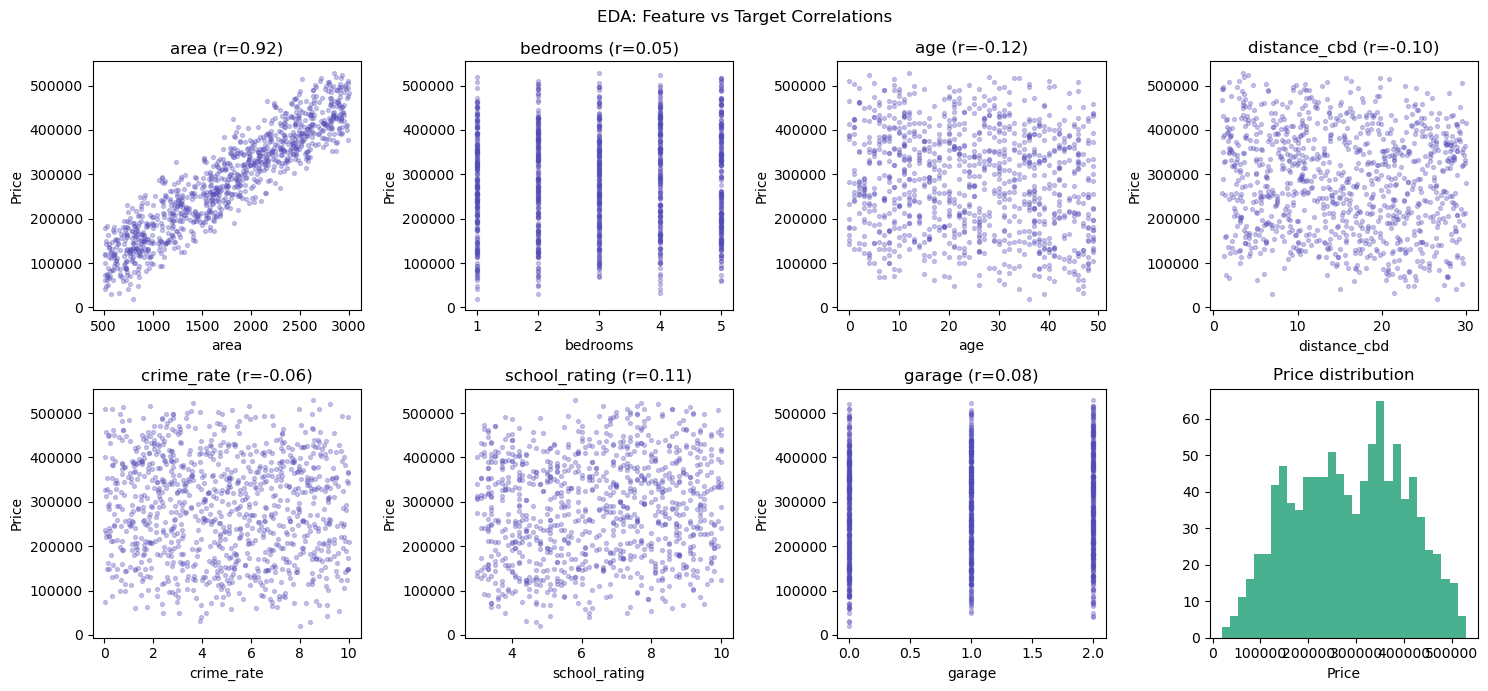

In [21]:
# ── 5.2  EDA Report ───────────────────────────────────────────────────────────
print('=== MISSING VALUES ===')
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print('\n=== NUMERIC STATS ===')
print(train_df.describe().round(1))

print('\n=== CATEGORY DISTRIBUTIONS ===')
for col in ['neighborhood', 'style']:
    print(f'{col}:', train_df[col].value_counts().to_dict())

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
num_cols = ['area','bedrooms','age','distance_cbd','crime_rate','school_rating','garage']

for ax, col in zip(axes.flatten()[:7], num_cols):
    ax.scatter(train_df[col], train_df['price'], alpha=0.3, s=8, color='#534AB7')
    ax.set_xlabel(col); ax.set_ylabel('Price')
    ax.set_title(f'{col} vs price')
    r = train_df[[col,'price']].dropna().corr().iloc[0,1]
    ax.set_title(f'{col} (r={r:.2f})')

# Price distribution
axes.flatten()[7].hist(train_df['price'], bins=30, color='#1D9E75', alpha=0.8)
axes.flatten()[7].set_title('Price distribution')
axes.flatten()[7].set_xlabel('Price')

plt.suptitle('EDA: Feature vs Target Correlations', fontsize=12)
plt.tight_layout(); plt.show()

In [22]:
# ── 5.3  Feature Engineering ──────────────────────────────────────────────────
def engineer_features(df):
    d = df.copy()
    # Fill missing values
    d['garage']       = d['garage'].fillna(d['garage'].median())
    d['school_rating'] = d['school_rating'].fillna(d['school_rating'].median())

    # New features
    d['area_per_bed']      = d['area'] / (d['bedrooms'] + 1)
    d['area_per_bath']     = d['area'] / (d['bathrooms'] + 1)
    d['total_rooms']       = d['bedrooms'] + d['bathrooms']
    d['age_sq']            = d['age'] ** 2
    d['log_area']          = np.log1p(d['area'])
    d['school_crime_ratio']= d['school_rating'] / (d['crime_rate'] + 1)
    d['is_large']          = (d['area'] > 1500).astype(int)
    d['is_new']            = (d['age'] < 10).astype(int)

    # Encode categoricals
    d = pd.get_dummies(d, columns=['neighborhood','style'], drop_first=False)
    return d

train_eng = engineer_features(train_df.drop('price', axis=1))
test_eng  = engineer_features(test_df)

# Align columns
train_eng, test_eng = train_eng.align(test_eng, join='left', axis=1, fill_value=0)

y_train = train_df['price'].values
print(f'Features: {train_df.shape[1]-1} → {train_eng.shape[1]} (after engineering)')
print('New columns:', [c for c in train_eng.columns if c not in train_df.columns])

Features: 11 → 23 (after engineering)
New columns: ['area_per_bed', 'area_per_bath', 'total_rooms', 'age_sq', 'log_area', 'school_crime_ratio', 'is_large', 'is_new', 'neighborhood_budget', 'neighborhood_premium', 'neighborhood_standard', 'style_classic', 'style_colonial', 'style_modern']


In [24]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# ── Example placeholders (REPLACE with your actual data) ────────────────────
# train_eng = your feature dataframe
# y_train   = your target variable

# Example (remove if you already have data)
# from sklearn.datasets import make_regression
# train_eng, y_train = make_regression(n_samples=500, n_features=10, noise=0.1, random_state=42)

# ── Model Definitions ──────────────────────────────────────────────────────
models = {
    'Ridge': make_pipeline(
        StandardScaler(),
        Ridge(alpha=10)
    ),
    
    'Random Forest': make_pipeline(
        StandardScaler(),  # not strictly needed, but kept for consistency
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    ),
    
    'Gradient Boosting': make_pipeline(
        StandardScaler(),  # optional for tree models
        GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        )
    ),
}

# ── Model Comparison Loop ──────────────────────────────────────────────────
leaderboard = []

for name, model in models.items():
    # R² scores
    scores_r2 = cross_val_score(
        model,
        train_eng,
        y_train,
        cv=5,
        scoring='r2'
    )
    
    # RMSE scores (negative → convert later)
    scores_rmse = cross_val_score(
        model,
        train_eng,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    
    leaderboard.append({
        'Model': name,
        'CV R²': round(scores_r2.mean(), 4),
        'CV RMSE': round(-scores_rmse.mean(), 4),
        'R² std': round(scores_r2.std(), 4),
    })

# ── Create Leaderboard ─────────────────────────────────────────────────────
lb_df = pd.DataFrame(leaderboard).sort_values(by='CV R²', ascending=False)

print('=== MODEL LEADERBOARD ===')
print(lb_df.to_string(index=False))

=== MODEL LEADERBOARD ===
            Model  CV R²    CV RMSE  R² std
            Ridge 0.9812 15836.7336  0.0012
Gradient Boosting 0.9719 19322.2154  0.0028
    Random Forest 0.9548 24520.5739  0.0040


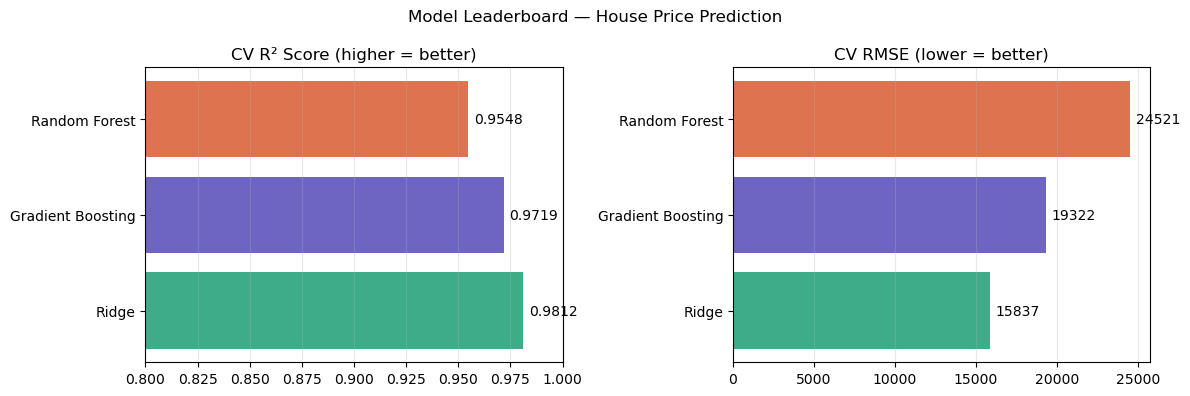

In [25]:
# ── 5.5  Leaderboard Plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#1D9E75','#534AB7','#D85A30']

axes[0].barh(lb_df['Model'], lb_df['CV R²'], color=colors, alpha=0.85)
axes[0].bar_label(axes[0].containers[0], fmt='%.4f', padding=4, fontsize=10)
axes[0].set_xlim(0.8, 1.0)
axes[0].set_title('CV R² Score (higher = better)')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(lb_df['Model'], lb_df['CV RMSE'], color=colors, alpha=0.85)
axes[1].bar_label(axes[1].containers[0], fmt='%.0f', padding=4, fontsize=10)
axes[1].set_title('CV RMSE (lower = better)')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Model Leaderboard — House Price Prediction', fontsize=12)
plt.tight_layout(); plt.show()

Validation R²   : 0.9687
Validation RMSE : 20,458
Validation MAE  : 16,416


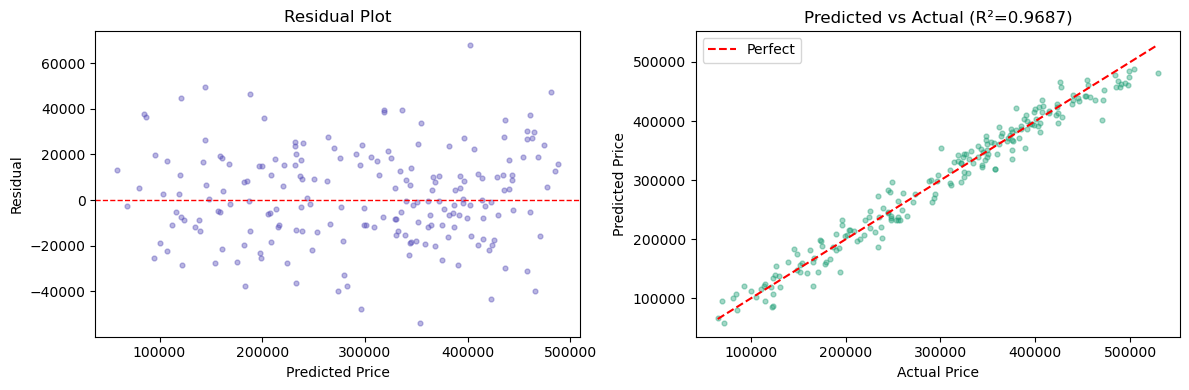

In [26]:
# ── 5.6  Train Best Model & Analyse Errors ────────────────────────────────────
best_model = make_pipeline(
    StandardScaler(),
    GradientBoostingRegressor(n_estimators=150, learning_rate=0.08,
                               max_depth=4, random_state=42)
)

X_tr, X_val, y_tr, y_val = train_test_split(train_eng, y_train,
                                              test_size=0.2, random_state=42)
best_model.fit(X_tr, y_tr)
y_val_pred = best_model.predict(X_val)

val_r2   = r2_score(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae  = mean_absolute_error(y_val, y_val_pred)

print(f'Validation R²   : {val_r2:.4f}')
print(f'Validation RMSE : {val_rmse:,.0f}')
print(f'Validation MAE  : {val_mae:,.0f}')

# Residual analysis
residuals = y_val - y_val_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_val_pred, residuals, alpha=0.4, s=12, color='#534AB7')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residual Plot')

axes[1].scatter(y_val, y_val_pred, alpha=0.4, s=12, color='#1D9E75')
mn, mx = y_val.min(), y_val.max()
axes[1].plot([mn,mx],[mn,mx],'r--', linewidth=1.5, label='Perfect')
axes[1].set_xlabel('Actual Price'); axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Predicted vs Actual (R²={val_r2:.4f})')
axes[1].legend()
plt.tight_layout(); plt.show()

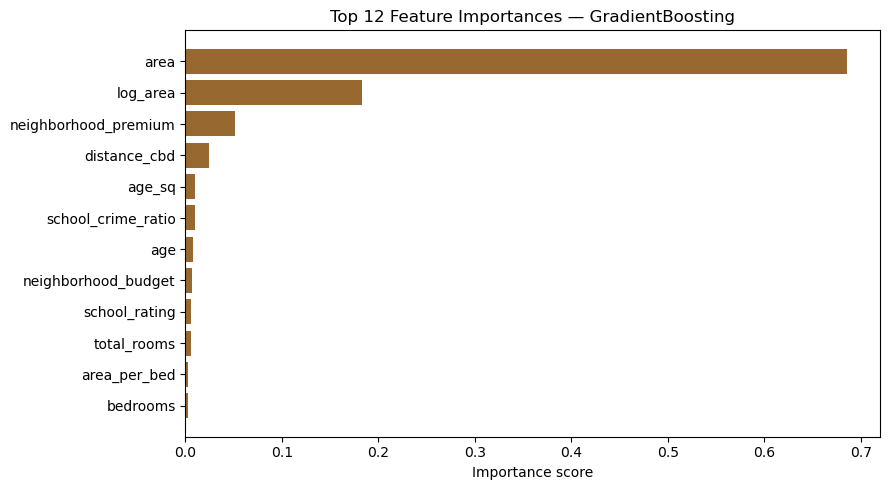

In [28]:
# ── 5.7  Feature Importance ───────────────────────────────────────────────────
gb_step = best_model.named_steps['gradientboostingregressor']
imp_df  = pd.DataFrame({
    'feature'    : train_eng.columns,
    'importance' : gb_step.feature_importances_
}).sort_values('importance', ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df['feature'], imp_df['importance'], color='#854F0B', alpha=0.85)
ax.set_title('Top 12 Feature Importances — GradientBoosting')
ax.set_xlabel('Importance score')
plt.tight_layout(); plt.show()

In [29]:
# ── 5.8  Generate Submission CSV ─────────────────────────────────────────────
# Re-train on full training data before predicting test
best_model.fit(train_eng, y_train)
test_preds = best_model.predict(test_eng)

submission = pd.DataFrame({
    'id'    : test_id,
    'price' : test_preds.round(2)
})
submission.to_csv('submission.csv', index=False)

print('=== SUBMISSION.CSV PREVIEW ===')
print(submission.head(10).to_string(index=False))
print(f'\nTotal rows      : {len(submission)}')
print(f'Predicted mean  : ${submission["price"].mean():,.0f}')
print(f'Predicted range : ${submission["price"].min():,.0f} — ${submission["price"].max():,.0f}')
print('\n✅ submission.csv saved!')

=== SUBMISSION.CSV PREVIEW ===
  id     price
1000 415824.67
1001 282294.89
1002 422090.78
1003 334632.55
1004 123642.60
1005 276700.02
1006 450732.78
1007 510062.05
1008 495376.43
1009 334371.58

Total rows      : 300
Predicted mean  : $281,865
Predicted range : $41,485 — $510,062

✅ submission.csv saved!
